# End-to-End ANN Project — Online Shoppers Purchase Intention

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna

import pickle
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\archive (6)\online_shoppers_intention.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


#  Basic Data Checks

In [4]:
df.duplicated().sum()

np.int64(125)

In [5]:
# Drop duplicates
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (12205, 18)


In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [8]:
df.head(1)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False


#  Feature Engineering

In [9]:
# Convert boolean columns to int
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

In [10]:
# Feature: Total pages visited across all categories
df["Total_Pages"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]

# Feature: Total time spent on site
df["Total_Duration"] = df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"]

# Feature: Engagement score (page value relative to bounce/exit)
df["Engagement_Score"] = df["PageValues"] / (df["BounceRates"] + df["ExitRates"] + 1e-5)

# Feature: Frequency encoding for VisitorType
visitor_freq = df["VisitorType"].value_counts(normalize=True)
df["VisitorType_Freq"] = df["VisitorType"].map(visitor_freq)

# Feature: Frequency encoding for Month
month_freq = df["Month"].value_counts(normalize=True)
df["Month_Freq"] = df["Month"].map(month_freq)

In [11]:
df.head(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region,TrafficType,VisitorType,Weekend,Revenue,Total_Pages,Total_Duration,Engagement_Score,VisitorType_Freq,Month_Freq
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,...,1,1,Returning_Visitor,0,0,1,0.0,0.0,0.85465,0.01483
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,...,1,2,Returning_Visitor,0,0,2,64.0,0.0,0.85465,0.01483


#  EDA (Exploratory Data Analysis)

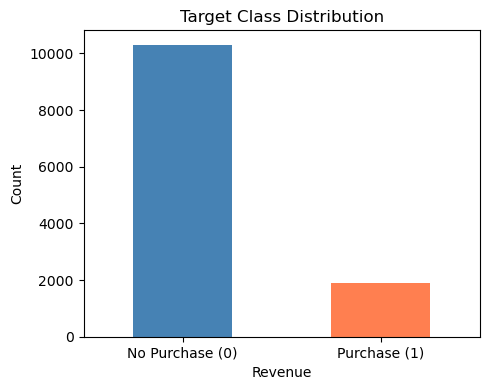

Revenue
0    10297
1     1908
Name: count, dtype: int64


In [12]:
# Target class distribution
plt.figure(figsize=(5, 4))
df["Revenue"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.xticks([0, 1], ["No Purchase (0)", "Purchase (1)"], rotation=0)
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(df["Revenue"].value_counts())

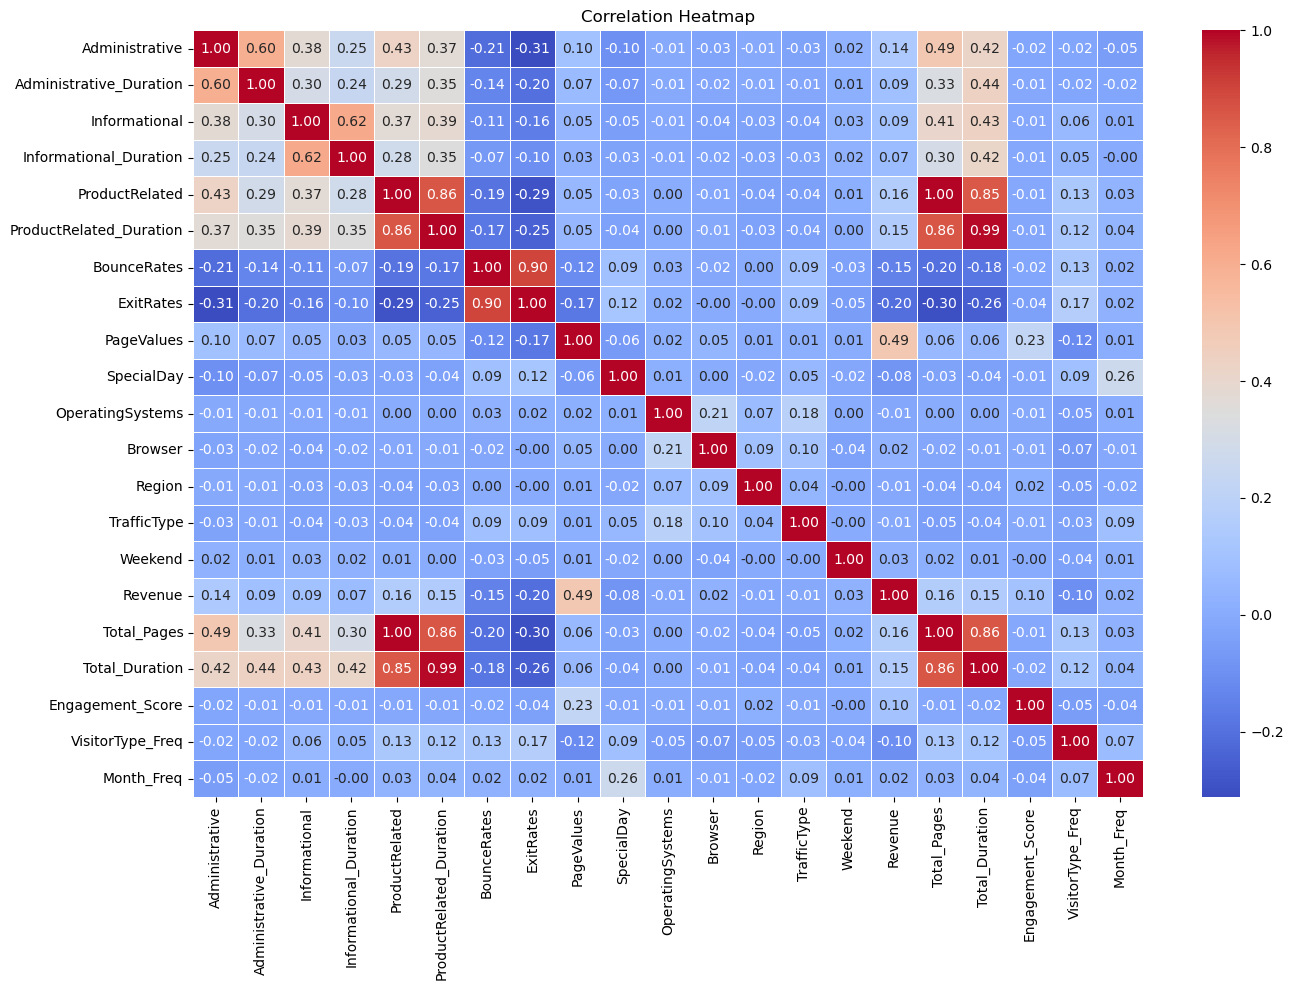

In [13]:
# Correlation heatmap (numeric columns)
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

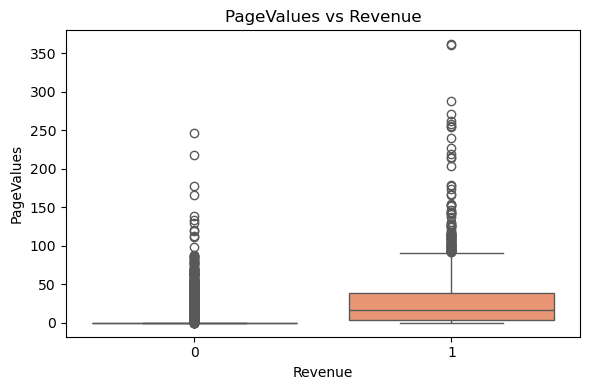

In [14]:
# PageValues vs Revenue
plt.figure(figsize=(6, 4))
sns.boxplot(x="Revenue", y="PageValues", data=df, palette="Set2")
plt.title("PageValues vs Revenue")
plt.tight_layout()
plt.show()

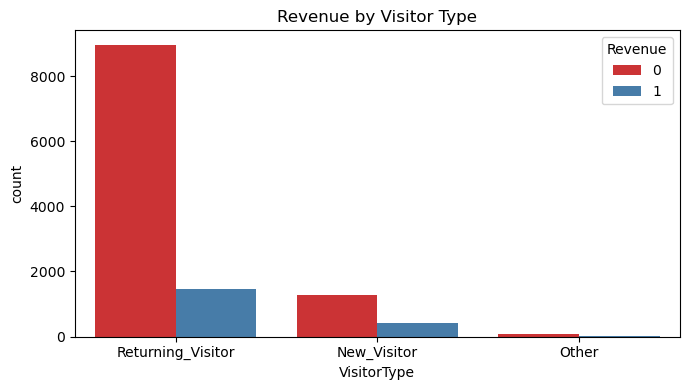

In [15]:
# Revenue by VisitorType
plt.figure(figsize=(7, 4))
sns.countplot(x="VisitorType", hue="Revenue", data=df, palette="Set1")
plt.title("Revenue by Visitor Type")
plt.tight_layout()
plt.show()

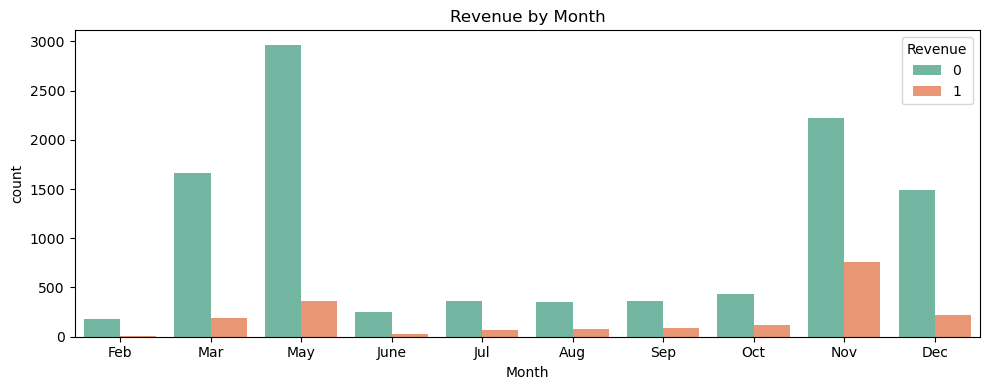

In [16]:
# Revenue by Month
month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
existing_months = [m for m in month_order if m in df["Month"].unique()]
plt.figure(figsize=(10, 4))
sns.countplot(x="Month", hue="Revenue", data=df, order=existing_months, palette="Set2")
plt.title("Revenue by Month")
plt.tight_layout()
plt.show()

# Define X and y

In [17]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12205, 22)
y shape: (12205,)


# Train / Validation / Test Split

In [18]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [19]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=21, stratify=y_train_full)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (7811, 22) | Val: (1953, 22) | Test: (2441, 22)


###  Preprocessing (Scaling + Encoding)

In [20]:
num_cols = X.select_dtypes(exclude="object").columns
cat_cols = X.select_dtypes(include="object").columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numeric columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Total_Pages', 'Total_Duration', 'Engagement_Score', 'VisitorType_Freq', 'Month_Freq']
Categorical columns: ['Month', 'VisitorType']


In [21]:
preprocessor = ColumnTransformer([
    ("Scaling",  MinMaxScaler(), num_cols),
    ("Encoding", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
], remainder="drop")

In [22]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

print("Transformed Train shape:", X_train_t.shape)

Transformed Train shape: (7811, 31)


# Baseline ANN Model (Before SMOTE)

In [23]:
model = Sequential([
    Input(shape=(X_train_t.shape[1],)),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1,  activation="sigmoid")
])

In [24]:
model.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["accuracy"])

In [25]:
early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

In [26]:
model.fit( X_train_t, y_train,epochs=50,validation_data=(X_val_t, y_val),batch_size=256,callbacks=[early],verbose=2)

Epoch 1/50
31/31 - 5s - 157ms/step - accuracy: 0.8293 - loss: 0.5352 - val_accuracy: 0.8438 - val_loss: 0.4437
Epoch 2/50
31/31 - 0s - 14ms/step - accuracy: 0.8437 - loss: 0.4285 - val_accuracy: 0.8438 - val_loss: 0.4153
Epoch 3/50
31/31 - 0s - 14ms/step - accuracy: 0.8437 - loss: 0.4069 - val_accuracy: 0.8438 - val_loss: 0.3990
Epoch 4/50
31/31 - 0s - 15ms/step - accuracy: 0.8438 - loss: 0.3923 - val_accuracy: 0.8438 - val_loss: 0.3901
Epoch 5/50
31/31 - 0s - 15ms/step - accuracy: 0.8441 - loss: 0.3822 - val_accuracy: 0.8454 - val_loss: 0.3800
Epoch 6/50
31/31 - 0s - 14ms/step - accuracy: 0.8460 - loss: 0.3717 - val_accuracy: 0.8449 - val_loss: 0.3678
Epoch 7/50
31/31 - 0s - 15ms/step - accuracy: 0.8487 - loss: 0.3604 - val_accuracy: 0.8454 - val_loss: 0.3608
Epoch 8/50
31/31 - 0s - 15ms/step - accuracy: 0.8530 - loss: 0.3499 - val_accuracy: 0.8561 - val_loss: 0.3445
Epoch 9/50
31/31 - 0s - 14ms/step - accuracy: 0.8571 - loss: 0.3384 - val_accuracy: 0.8612 - val_loss: 0.3342
Epoch 10/

In [27]:
y_pred = np.where(model.predict(X_test_t) > 0.5, 1, 0)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step   
Baseline Accuracy: 0.8918476034412126


# Handle Class Imbalance with SMOTE

In [28]:
smote = SMOTE(random_state=21)
X_train_res, y_train_res = smote.fit_resample(X_train_t, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 6590, 1: 1221}
After  SMOTE: {1: 6590, 0: 6590}


# Hyperparameter Tuning with Optuna

In [29]:
def objective(trial):
    lr_rate       = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers      = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation    = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1   = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))

    for i in range(n_layers):
        units   = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg     = trial.suggest_float(f'reg{i}', 1e-5, 1e-2, log=True)
        model.add(Dense(units, activation=activation, kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam':    Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD':     SGD(learning_rate=lr_rate)
    }
    model.compile(
        optimizer=opt_map[optimizer_name],
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.Recall(name='recall')]
    )

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [30]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)

[I 2026-07-02 12:16:38,781] A new study created in memory with name: no-name-3a7893df-6986-494a-b003-c4a401c19d9a


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-07-02 12:16:50,094] Trial 0 finished with value: 0.8918032646179199 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 0.00030746001885481724, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 0.008155589837765905}. Best is trial 0 with value: 0.8918032646179199.
[I 2026-07-02 12:17:12,345] Trial 1 finished with value: 0.911475419998169 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 0.0004296403664910425, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 0.001513747182776292}. Best is trial 1 with value: 0.911475419998169.
[I 2026-07-02 12:17:30,548] Trial 2 finished with value: 1.0 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 're

# Final Optimized ANN Model (Best Params from Optuna)

In [42]:
best = study.best_params
print("Best Params:", best)

Best Params: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 64, 'units0': 78, 'dropout0': 0.4438277186036015, 'reg0': 0.00124905731421375, 'units1': 48, 'dropout1': 0.15295758239442775, 'reg1': 0.0028857135238802138}


In [43]:
final_model = Sequential()

# Input Layer
final_model.add(Input(shape=(X_train_res.shape[1],)))

# Hidden Layers (using best params from Optuna)
for i in range(best['n_layers']):
    final_model.add(Dense(
        best[f'units{i}'],
        activation=best['activation'],
        kernel_initializer='he_normal',
        kernel_regularizer=l1_l2(l1=best[f'reg{i}'], l2=best[f'reg{i}'])
    ))
    final_model.add(BatchNormalization())
    final_model.add(Dropout(best[f'dropout{i}']))

# Output Layer
final_model.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))

final_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 78)                  │           2,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 78)                  │             312 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 78)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 48)                  │           3,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,841 (26.72 KB)

 Trainable params: 6,589 (25.74 KB)

 Non-trainable params: 252 (1008.00 B)

In [44]:
opt_map = {'Adam':    Adam(learning_rate=best['learning_rate']),
           'RMSprop': RMSprop(learning_rate=best['learning_rate']),
           'SGD':     SGD(learning_rate=best['learning_rate'])}

final_model.compile(optimizer=opt_map[best['optimizer']],
                    loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

In [45]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [46]:
history = final_model.fit(X_train_res, y_train_res,epochs=30,batch_size=best['batch_size'],validation_data=(X_val_t, y_val),callbacks=[es],verbose=2)

Epoch 1/30
206/206 - 8s - 40ms/step - accuracy: 0.7128 - loss: 1.2967 - recall: 0.7331 - val_accuracy: 0.6692 - val_loss: 0.8559 - val_recall: 0.9148
Epoch 2/30
206/206 - 2s - 7ms/step - accuracy: 0.8137 - loss: 0.5617 - recall: 0.8370 - val_accuracy: 0.8776 - val_loss: 0.5832 - val_recall: 0.7639
Epoch 3/30
206/206 - 2s - 8ms/step - accuracy: 0.8322 - loss: 0.4920 - recall: 0.8473 - val_accuracy: 0.8397 - val_loss: 0.4636 - val_recall: 0.8295
Epoch 4/30
206/206 - 2s - 8ms/step - accuracy: 0.8329 - loss: 0.4812 - recall: 0.8519 - val_accuracy: 0.7880 - val_loss: 0.5412 - val_recall: 0.8787
Epoch 5/30
206/206 - 2s - 7ms/step - accuracy: 0.8347 - loss: 0.4759 - recall: 0.8493 - val_accuracy: 0.8034 - val_loss: 0.4952 - val_recall: 0.8525
Epoch 6/30
206/206 - 2s - 7ms/step - accuracy: 0.8322 - loss: 0.4721 - recall: 0.8432 - val_accuracy: 0.7465 - val_loss: 0.5702 - val_recall: 0.9016


# Evaluate the Final Model

In [47]:
y_pred_test = np.where(final_model.predict(X_test_t) > 0.5, 1, 0)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   
Test Accuracy: 0.6775911511675543


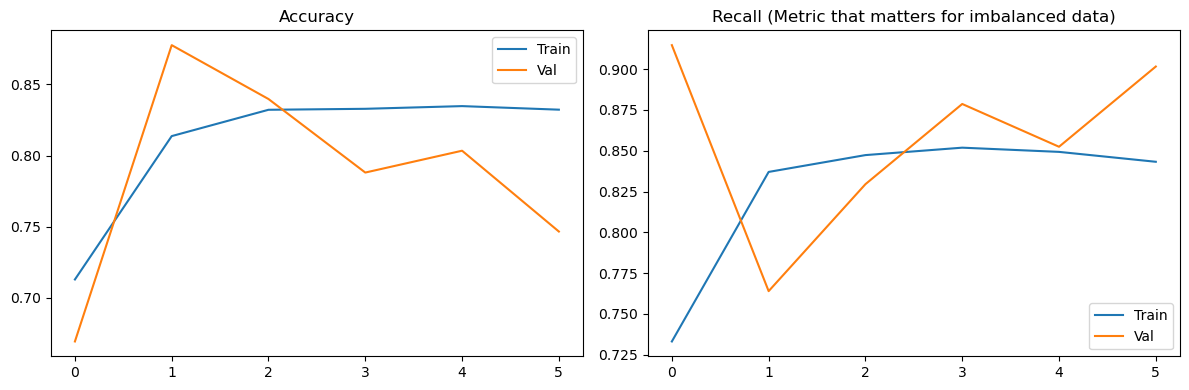

In [48]:
# Training / Validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['recall'],     label='Train')
axes[1].plot(history.history['val_recall'], label='Val')
axes[1].set_title('Recall (Metric that matters for imbalanced data)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [49]:
# Train / Val / Test accuracy comparison
y_pred_train = np.where(final_model.predict(X_train_res) > 0.5, 1, 0)
y_pred_val   = np.where(final_model.predict(X_val_t)     > 0.5, 1, 0)
y_pred_test  = np.where(final_model.predict(X_test_t)    > 0.5, 1, 0)

print(f"Train Accuracy      : {accuracy_score(y_train_res, y_pred_train):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Test Accuracy       : {accuracy_score(y_test, y_pred_test):.4f}")

412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Train Accuracy      : 0.7813
Validation Accuracy : 0.6692
Test Accuracy       : 0.6776


In [50]:
# Classification Report
print(classification_report(y_test, y_pred_test, target_names=['No Purchase', 'Purchase']))

              precision    recall  f1-score   support

 No Purchase       0.97      0.64      0.77      2059
    Purchase       0.31      0.90      0.47       382

    accuracy                           0.68      2441
   macro avg       0.64      0.77      0.62      2441
weighted avg       0.87      0.68      0.72      2441



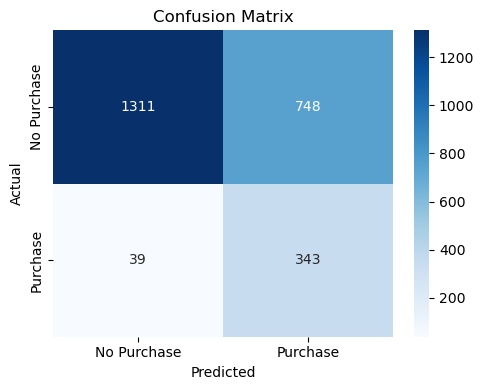

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Save Model & Preprocessor

In [52]:
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

final_model.save('online_shoppers_model.keras')
print("Saved preprocessor.pkl and online_shoppers_model.keras")

Saved preprocessor.pkl and online_shoppers_model.keras
